In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

(21, 12)
m_fit = 0.02


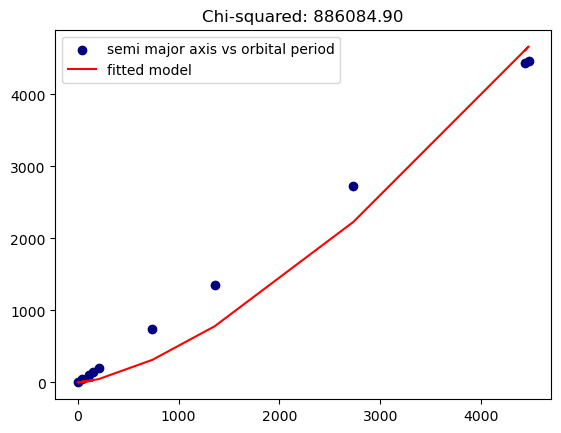

In [2]:
solar_system = pd.read_csv("../../course_assignments/homework9/solar_system.csv")
# print(solar_system.shape) #20 rows 11 cols
# print(solar_system.head(),solar_system.tail())
# print(solar_system.loc[0])
# print(solar_system.index)
perihelion = solar_system.iloc[8] #point in orbit closest to sun
aphelion = solar_system.iloc[9] #point in orbit farthest to sun
orbital_period = solar_system.iloc[10] #time to do a full orbit

perihelion = pd.to_numeric(perihelion, errors='coerce')
aphelion = pd.to_numeric(aphelion, errors='coerce')
orbital_period = pd.to_numeric(orbital_period, errors='coerce')
perihelion = perihelion.dropna()
aphelion = perihelion.dropna()
orbital_period = perihelion.dropna()

semi_major_axis = (perihelion + aphelion)/2

solar_system.loc[len(solar_system)] = semi_major_axis
solar_system[20, "Attribute"] = "semi_major_axis"
print(solar_system.shape)#21 rows 12 cols

x = semi_major_axis
y = orbital_period
plt.scatter(x,y,label = "semi major axis vs orbital period", color = "navy")
plt.legend()
plt.title("semi major axis vs orbital period")

def keplers_third_law(a, m):
    return m * a ** 1.5

popt, pcov = curve_fit(keplers_third_law, x, y)
m_fit = popt
print(f"m_fit = {m_fit[0]:.2f}")

residuals = y - keplers_third_law(x, m_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

plt.plot(x,keplers_third_law(x,m_fit),label = "fitted model",color = "red")
plt.legend()
plt.title(f"Chi-squared: {chi2:.2f}")
plt.show()

solar_system.to_csv("kepler.csv", index=False)